# ROI | Draw and Reuse Regions of Interest
-----------------------------------------

## Setup and Configuration

In [10]:
##### Imports ##########################################################################

#==== Generic Imports ================
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import display

#==== Movement Imports ===============
import movement.kinematics

#==== DataConduit Imports (Core) =====
from data_conduit.datastructures import slice_stream, slice_stream_per_trial
from data_conduit.integrations.DLC.pose import pose_to_movement     # Combine aligned pose and confidence in movement format.

#==== DataConduit Imports (Unique) ===
from movement_figures.data_template.loading import build_datastructure
from movement_figures.misc import visual_streams_check, configure_simplified_trial_df
from data_conduit.refactor_qc import (
    TRAINING_FIRST_MID_LAST_DETAIL,
    training_spec,
    filter_trials,
)

#==== Imports for This Figure =========
import movement.roi
from movement_figures.video import read_session_video_frame

### Notebook Settings ######################################################

pd.set_option('display.max_columns', None)                         # Show all trial columns during inspection.
pd.set_option('display.max_rows', None)


In [11]:
##### Setup Parameters #################################################################

# === 1| Select Mice, Days and Recording Folders Before Reading Files =============
ROOT = Path("/media/sepi/Elements/PathIntegrationProtocol/BonsaiOutput/Training")

LEVEL_SELECTORS = {
    'l0_selector': 'MR_M01569515', 
    'l1_selector': 'Day21'
    }                                                                                       # Example choices belong here: l0_selector and l1_selector.
# INCLUDE_SESSIONS = ('2026-06-21T093349Z',)                                                # Optional list of recording folder names; None keeps selected folders.
# STREAMS = ('trials', 'events', 'video', 'dlc')                                            # These figures require events/trials and aligned pose; other sources remain available.


#=== 2| Set the trial filtering parameters for the experiment protocol ============
spec = training_spec(TRAINING_FIRST_MID_LAST_DETAIL)                                        # Flattens `{training_detail}` table into per-session spec. 

# included_sessions = training_session_names(spec)                                          # Returns a list of session folder names that match the spec.
#   Not used here, as sessions have been filtered in another way. If other sessions 
#   not in the above spec are used, then applying the `filter_trials` function with 
#   the above spec could result in incorrect filtering.


In [12]:
##### Load DataStructure ###############################################################

#=== Load data ========================================================================

fig_ds_obj = build_datastructure(
    root               = ROOT,                                                                 # Directory above the named hierarchy levels.
    level_names        = ("mouseID", "day"),                                                   # Lab layout: root / mouseID / day / session.
    streams            = ("trials", "session_settings", "video", "dlc"),                       # Data streams to be included in the datastructure.
    include            = None,                                                                 # Keep these session folder names; None keeps all.
    exclude            = None,                                                                 # Alternatively omit these session folder names.
    raw_events         = True,                                                                 # Convenience alias for adding "events" to the requested sources.
    device_yaml        = "./device.yml",                                                       # Lab Nosepoke board register definitions.
    soundcard_yaml     = "./soundcard.yml",                                                    # Lab SoundCard register definitions.
    nosepoke_count     = 18,                                                                   # Port count used by the existing Q_C parser.
    trial_start_buffer = 0.0,                                                                  # Preserve the existing lab parser setting.
    dlc_file_format     = "auto",                                                              # Existing reader prefers CSV, otherwise HDF5.
    trial_spec = None,                                                                         # Optional experiment rules; None keeps the existing Q_C specification. 
    #    Not used here, as sessions are already selected. 
    #    If session is not one in the spec, then subsequent use of 
    #   `filter_trials` to apply correct experiment protocol rules could be incorrect.
    
    **LEVEL_SELECTORS,
)


#=== Select and load the streams of interest from datastructure. ======================
fig_ds_obj.select()
streams = fig_ds_obj.load()                                                                    # Load is required to access the selected streams.

#=== Create convenient compact trial dataframe without some unnecessary columns. ======
streams['compact_trials'] = configure_simplified_trial_df(              
    trial_df = streams['trials'],
    modify_in_place = False,                                                                   # Whether to modify the trial dataframe in place or return a new dataframe. 
)
'''More useful for visual inspection and analysis. 
Check the misc.py file for the default columns to keep and drop.'''


#=== Apply Trial Filtering Protocol to construct new stream objects ===================

# Full filtered trials
streams['filtered_trials'] = filter_trials(
    trials = streams['trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

# Filtered compact trials 
streams['filtered_compact_trials'] = filter_trials(
    trials = streams['compact_trials'],
    spec = spec,
    # session_column = 'session', mouse_column = 'mouseID', trial_index_column = 'trial_index', led_column = 'LED', report = True,
    #                                                            # Leave params untouched for now, let the function use its defaults.
)

#=== Merge Pose & Confidence Streams ==================================================
streams['dlc:movement'] = pose_to_movement(
    slice_stream(streams["dlc:position"],   
                #selectors={"session": session_id}
    ),
    slice_stream(streams["dlc:confidence"], 
                 #selectors={"session": session_id}
    ),
)

#=== Visual streams check =============================================================
visual_streams_check(
    loaded_ds_object = streams,                                                                # Loaded dataset object containing all streams of interest.
    show_stream_shapes = True,                                                                 # Whether to display the shapes of the streams.
    show_stream_dtypes = True,                                                                 # Whether to display the data types of the streams.
    display_streams = False                                                                    # Whether to display the actual stream data as a table.
)



     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80
     mouseID  training_day            session  n_total  min_trial  n_after_cut  exclude_on  n_on_dropped  n_kept
MR_M01569515             3 2026-06-21T093349Z      106         24           83        True             3      80


=========================
### Summary of Loaded Streams
=========================

,Stream Name,Shape,Type
0,session_settings:metadata,"(1, 23)",DataFrame
1,session_settings:trials,"(303, 132)",DataFrame
2,video,"(36354, 5)",DataFrame
3,dlc:position,"(36354, 5, 2)",DataArray
4,dlc:confidence,"(36354, 5)",DataArray
5,events,"(1487, 5)",DataFrame
6,trials,"(106, 28)",DataFrame
7,compact_trials,"(106, 19)",DataFrame
8,filtered_trials,"(80, 30)",DataFrame
9,filtered_compact_trials,"(80, 21)",DataFrame


## Select Trials to Show

In [13]:
##### Trial Selection ##################################################################

#==== Extract Trial Range ============
selected_trials = slice_stream(streams['filtered_trials'][:8])              # Select the first n trials

#==== Extract Recording Identifier ===
sessionID = selected_trials['session'].unique().item()                      # Extract unique sID from selected trials, remove duplicates, ensure single value.

#==== Select Tracked Positions =======
recording = slice_stream(stream = streams['dlc:movement'],                  # selectors{} here keeps movement data belonging to the specified session only.
                        selectors = {'session' : sessionID }, 
)

position = recording['position']                                            # ['position'] extracts positional data from the movement stream.

position = position.sel(individual='individual_0',                          # .sel() selects the specified individual from the positional data.
                        drop=True,                                          # drop=True removes the individual dimension from the resulting DataArray, but leaves other dims intact.
)


## Read the Video Background

In [14]:
##### Read the Matching Video Frame ####################################################

#==== Read the Selected Recording ======
background_frame, video_path = read_session_video_frame(
    session_path = fig_ds_obj.sessions[sessionID].path,           # Use the video belonging to the selected pose recording.
)


## Draw ROIs with movement

Run this section in a local notebook with the movement napari plugin available. In the movement dock, open **Define regions of interest**, click **Add new layer**, draw the arena outline, and name the polygon `arena`. Use **Save layer** to save it as `arena.geojson` in this notebook's working directory. Add separately named target regions to the same layer as needed.

These are static regions drawn in the video's coordinates, not automatic object tracking. Reference: [movement ROI drawing](https://movement.neuroinformatics.dev/latest/examples/boundary_angles.html#define-regions-of-interest).

In [15]:
##### Open the Native ROI Drawing Interface ############################################

#==== Open the Matching Video Frame =====
%gui qt
import napari

viewer = napari.Viewer()
viewer.add_image(background_frame, name=f'Video | {sessionID}')
viewer.window.add_plugin_dock_widget('movement', 'movement')       # Use movement's own region-drawing and export controls.


(<napari._qt.widgets.qt_viewer_dock_widget.QtViewerDockWidget at 0x7a46e4265310>,
 <movement.napari.meta_widget.MovementMetaWidget at 0x7a46f01813b0>)

## Load the Saved ROIs

In [17]:
##### Load Regions Defined in the GUI ##################################################

#==== Read the Saved Geometry ===========
ROI_PATH = Path('/home/sepi/dataconduit_workspace/data-conduit-refactor/data-conduit/src/movement_figures/Figures/Notebooks_v2/ROI/pokes.geojson')                                  # Same filename chosen in the GUI's Save layer dialog.
ROIs = movement.roi.load_rois(file=ROI_PATH)
ROIs_by_name = {ROI.name: ROI for ROI in ROIs}

#==== Show the Saved Region Names =======
display(pd.DataFrame({
    'Name': [ROI.name for ROI in ROIs],
    'Type': [type(ROI).__name__ for ROI in ROIs],
}))


,Name,Type
0,region,PolygonOfInterest
1,region_1,PolygonOfInterest
2,region_2,PolygonOfInterest
3,region_3,PolygonOfInterest
4,region_4,PolygonOfInterest
5,region_5,PolygonOfInterest
6,region_6,PolygonOfInterest
7,region_7,PolygonOfInterest
8,region_8,PolygonOfInterest
9,region_9,PolygonOfInterest


(<Figure size 640x480 with 1 Axes>, <Axes: >)

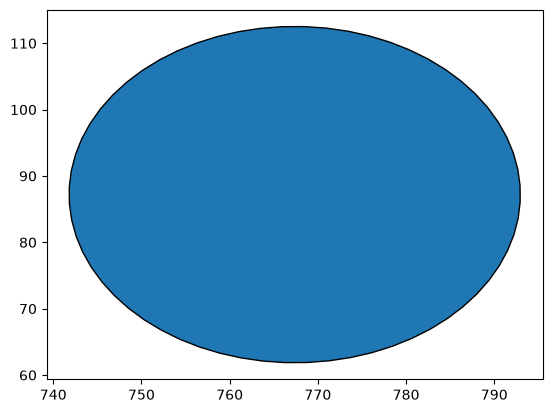

In [28]:
type(ROIs)
type(ROIs[0])

fig, ax = plt.subplots()
ROIs[0]._plot(fig=fig, ax=ax)

## ROI Plotting Function

In [29]:
##### Plot Saved ROIs on Ax #############################################################


def plot_ax_rois(
    ax: plt.Axes,
    rois: list,
    background_frame: np.ndarray,
    subtitle: str | None = 'Drawn Regions of Interest',
    **kwargs,
) -> plt.Axes:
    """Plot saved movement ROIs over the video frame used to draw them.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis on which to draw the overlay.
    rois : list
        Already-defined movement ROI objects in video-pixel coordinates.
    background_frame : numpy.ndarray
        Matching, unscaled video frame.
    subtitle : str or None
        Plot title. None omits it.
    **kwargs
        Arguments passed to each ROI's plot method, such as alpha and linewidth.

    Returns
    -------
    matplotlib.axes.Axes
        Supplied axis with the named ROI geometries over the video.
    """
    #==== 1| Draw the Original Video Frame ============================
    height, width = background_frame.shape[:2]
    extent = (-0.5, width - 0.5, height - 0.5, -0.5)
    ax.imshow(background_frame, origin='upper', extent=extent)


    #==== 2| Draw Each Region Using movement ==========================
    for roi in rois:
        roi.plot(ax=ax, label=roi.name, **kwargs)


    #==== 3| Set the Pixel Axes and Identify the Regions ==============
    ax.set(xlim=extent[:2], ylim=extent[2:], aspect='equal',
           xlabel='x (Pixels)', ylabel='y (Pixels)')
    ax.legend()

    if subtitle is not None:
        ax.set_title(subtitle)

    return ax


## Generate Plot

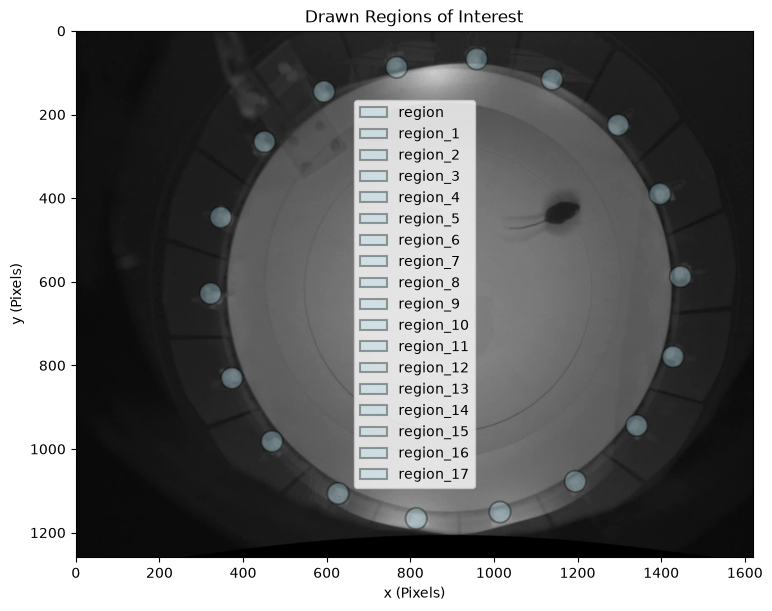

In [30]:
##### Plot the Saved ROI Definitions ###################################################

fig, ax = plt.subplots(figsize=(8, 6), layout='constrained')

ax = plot_ax_rois(
    ax               = ax,
    rois             = ROIs,
    background_frame = background_frame,
    subtitle         = 'Drawn Regions of Interest',
    alpha            = 0.35,                                     # Keep the video visible through filled regions.
    linewidth        = 1.5,
)

fig.savefig('drawn_rois.svg', bbox_inches='tight')
plt.show()


The spatial notebooks load this file as `../ROI/arena.geojson` when run from their own folders. Update the explicit path when using a different working directory. The exported SVG contains vector ROI shapes over the raster video frame.